In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_style("whitegrid")

In [2]:
np.random.seed(42)

num_days = 100
temperature = np.random.uniform(low=0, high=35, size=num_days)

intercept = 1.5
slope = 0.08
log_expected_rentals = intercept + slope * temperature

expected_rentals = np.exp(log_expected_rentals)
bike_rentals = np.random.poisson(lam=expected_rentals)

df = pd.DataFrame({
    'temperature': temperature,
    'bike_rentals': bike_rentals
})

print(df.head())

   temperature  bike_rentals
0    13.108904            11
1    33.275001            77
2    25.619788            33
3    20.953047            20
4     5.460652            12


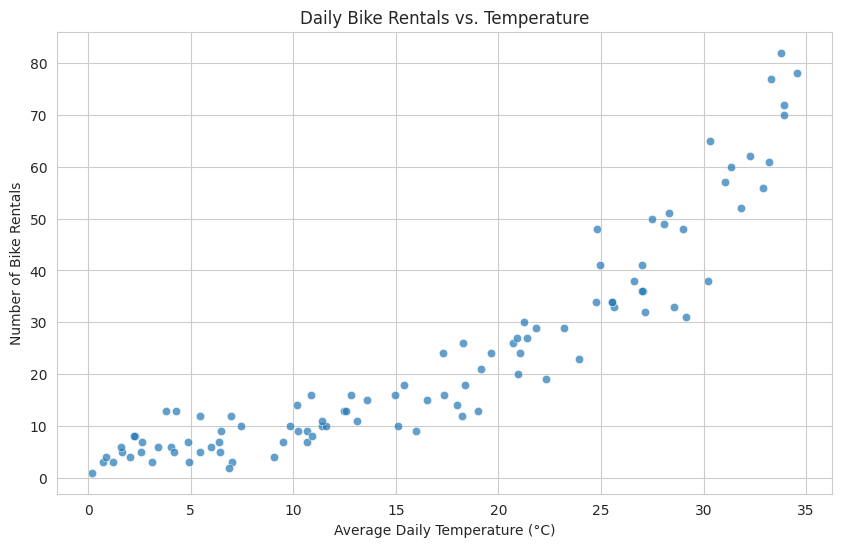

In [3]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='temperature', y='bike_rentals', data=df, alpha=0.7)
plt.title('Daily Bike Rentals vs. Temperature')
plt.xlabel('Average Daily Temperature (°C)')
plt.ylabel('Number of Bike Rentals')
plt.show()

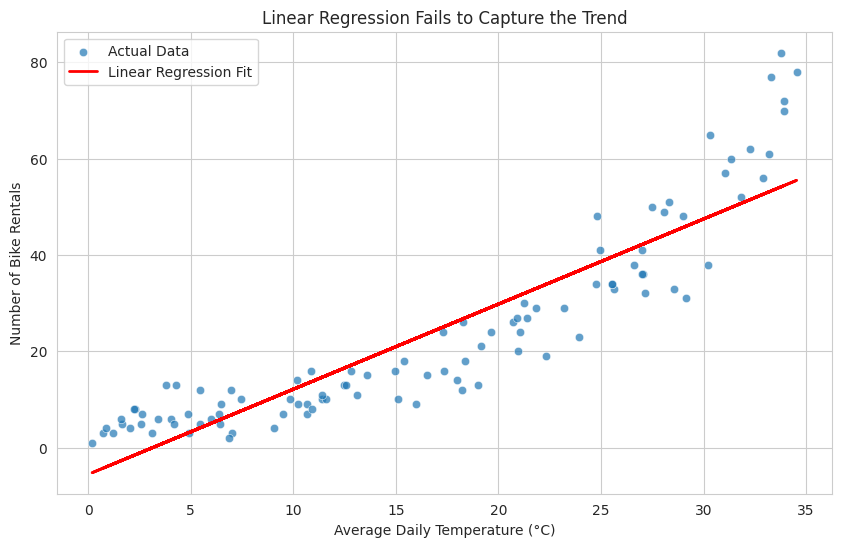

In [4]:
ols_model = smf.ols('bike_rentals ~ temperature', data=df).fit()

df['ols_pred'] = ols_model.predict(df['temperature'])

plt.figure(figsize=(10, 6))
sns.scatterplot(x='temperature', y='bike_rentals', data=df, alpha=0.7, label='Actual Data')
plt.plot(df['temperature'], df['ols_pred'], color='red', linewidth=2, label='Linear Regression Fit')
plt.title('Linear Regression Fails to Capture the Trend')
plt.xlabel('Average Daily Temperature (°C)')
plt.ylabel('Number of Bike Rentals')
plt.legend()
plt.show()

In [5]:
poisson_model = smf.glm(formula='bike_rentals ~ temperature', data=df, family=sm.families.Poisson()).fit()

print(poisson_model.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:           bike_rentals   No. Observations:                  100
Model:                            GLM   Df Residuals:                       98
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -289.40
Date:                Thu, 09 Oct 2025   Deviance:                       117.95
Time:                        17:41:34   Pearson chi2:                     118.
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       1.4406      0.061     23.438      

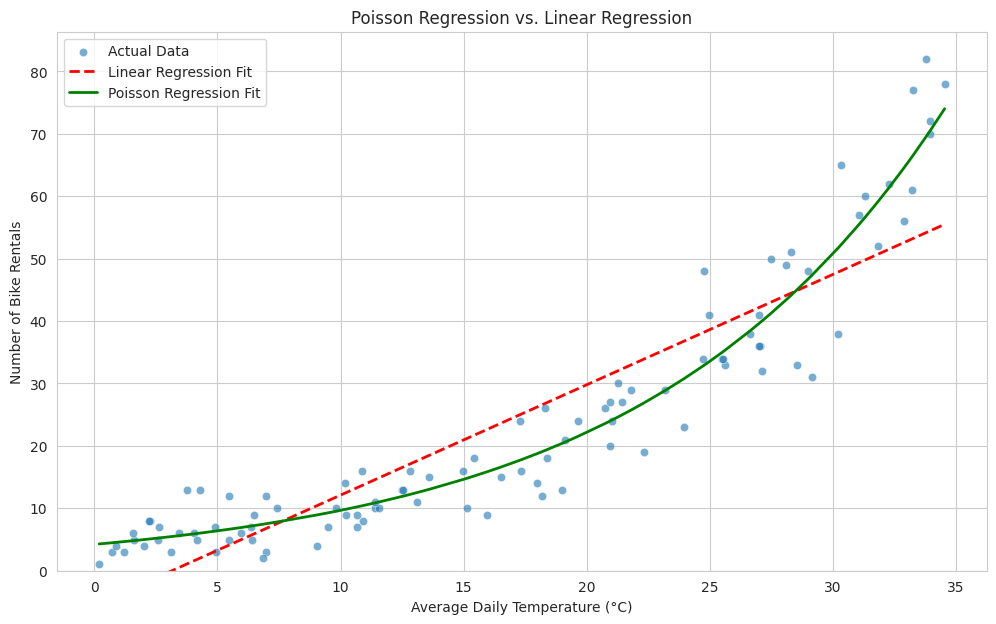

In [6]:
df['poisson_pred'] = poisson_model.predict(df['temperature'])

df_sorted = df.sort_values('temperature')

plt.figure(figsize=(12, 7))
sns.scatterplot(x='temperature', y='bike_rentals', data=df, alpha=0.6, label='Actual Data')
plt.plot(df_sorted['temperature'], df_sorted['ols_pred'], color='red', linewidth=2, linestyle='--', label='Linear Regression Fit')
plt.plot(df_sorted['temperature'], df_sorted['poisson_pred'], color='green', linewidth=2, label='Poisson Regression Fit')

plt.title('Poisson Regression vs. Linear Regression')
plt.xlabel('Average Daily Temperature (°C)')
plt.ylabel('Number of Bike Rentals')
plt.legend()
plt.ylim(bottom=0)
plt.show()